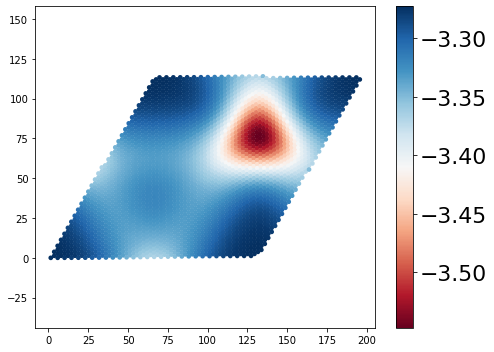

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
#step1 load data
tb_ri=np.genfromtxt("tB_ri")
bb_ri=np.genfromtxt("bB_ri")
tn_ri=np.genfromtxt("tN_ri")
bn_ri=np.genfromtxt("bN_ri")

tb_re=np.genfromtxt("tB_re")
bb_re=np.genfromtxt("bB_re")
tn_re=np.genfromtxt("tN_re")
bn_re=np.genfromtxt("bN_re")

# tB_x = np.loadtxt('tb_ri',usecols=(0,))
# tB_y = np.loadtxt('tb_ri',usecols=(1,))
# tB_z = np.loadtxt('tb_ri',usecols=(2,))
# tN_x = np.loadtxt('tn_ri',usecols=(0,))
# tN_y = np.loadtxt('tn_ri',usecols=(1,))
# tN_z = np.loadtxt('tn_ri',usecols=(2,))
# bB_x = np.loadtxt('bb_ri',usecols=(0,))
# bB_y = np.loadtxt('bb_ri',usecols=(1,))
# bB_z = np.loadtxt('bb_ri',usecols=(2,))
# bN_x = np.loadtxt('bn_ri',usecols=(0,))
# bN_y = np.loadtxt('bn_ri',usecols=(1,))
# bN_z = np.loadtxt('bn_ri',usecols=(2,))

tB_x = np.loadtxt('tb_re',usecols=(0,))
tB_y = np.loadtxt('tb_re',usecols=(1,))
tB_z = np.loadtxt('tb_re',usecols=(2,))
tN_x = np.loadtxt('tn_re',usecols=(0,))
tN_y = np.loadtxt('tn_re',usecols=(1,))
tN_z = np.loadtxt('tn_re',usecols=(2,))
bB_x = np.loadtxt('bb_re',usecols=(0,))
bB_y = np.loadtxt('bb_re',usecols=(1,))
bB_z = np.loadtxt('bb_re',usecols=(2,))
bN_x = np.loadtxt('bn_re',usecols=(0,))
bN_y = np.loadtxt('bn_re',usecols=(1,))
bN_z = np.loadtxt('bn_re',usecols=(1,))
#z-dispalcement
plt.figure(figsize=(7,5))
order= np.argsort(bB_x)
f_interp = scipy.interpolate.griddata((tB_x, tB_y), tB_z, (bB_x, bB_y),method="linear")
diff = f_interp-bB_z
plt.scatter(bB_x[order],bB_y[order],c=diff[order],s=22,cmap='RdBu',edgecolor='none')
plt.axis('equal')
plt.colorbar( ).ax.tick_params(labelsize=22)
plt.tight_layout()



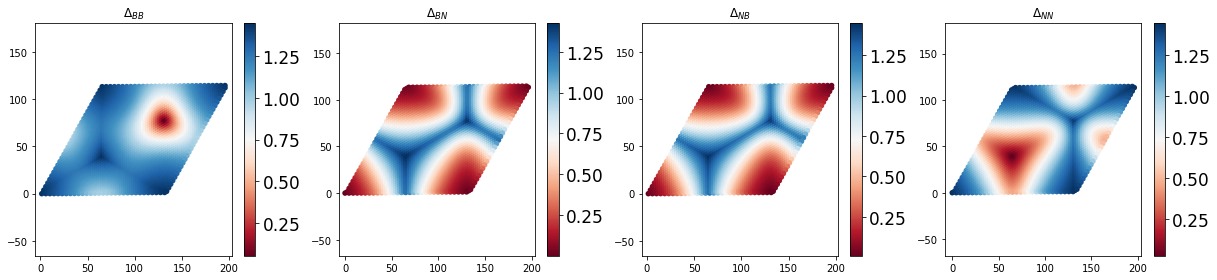

In [12]:
#xy_displacement
a=132.33893899756035
T = a*np.array([[1,0],[0.5,np.sqrt(3)/2]])
tB_x = np.append(tB_x,tB_x-1*T[0,0])
tB_y = np.append(tB_y,tB_y-1*T[0,1])
tB_x = np.append(tB_x,tB_x-1*T[1,0])
tB_y = np.append(tB_y,tB_y-1*T[1,1])
tB_x = np.append(tB_x,tB_x+1*T[0,0])
tB_y = np.append(tB_y,tB_y+1*T[0,1])
tB_x = np.append(tB_x,tB_x+1*T[1,0])
tB_y = np.append(tB_y,tB_y+1*T[1,1])

tN_x = np.append(tN_x,tN_x-1*T[0,0])
tN_y = np.append(tN_y,tN_y-1*T[0,1])
tN_x = np.append(tN_x,tN_x-1*T[1,0])
tN_y = np.append(tN_y,tN_y-1*T[1,1])
tN_x = np.append(tN_x,tN_x+1*T[0,0])
tN_y = np.append(tN_y,tN_y+1*T[0,1])
tN_x = np.append(tN_x,tN_x+1*T[1,0])
tN_y = np.append(tN_y,tN_y+1*T[1,1])

del_r_bb = []
del_r_bn = []
del_r_nb = []
del_r_nn = []

for elx, ely in zip(bB_x,bB_y):
    dx = tB_x-elx
    dy = tB_y-ely
    dr_BB = np.sqrt(dx**2 + dy**2).min()
    del_r_bb.append(dr_BB)
for elx, ely in zip(bN_x,bN_y):
    dx = tB_x-elx
    dy = tB_y-ely
    dr_BN = np.sqrt(dx**2 + dy**2).min()
    del_r_bn.append(dr_BN)
for elx, ely in zip(bB_x,bB_y):
    dx = tN_x-elx
    dy = tN_y-ely
    dr_NB = np.sqrt(dx**2 + dy**2).min()
    del_r_nb.append(dr_NB)
for elx, ely in zip(bN_x,bN_y):
    dx = tN_x-elx
    dy = tN_y-ely
    dr_NN = np.sqrt(dx**2 + dy**2).min()
    del_r_nn.append(dr_NN)   
del_r_bb=np.array(del_r_bb)
del_r_bn=np.array(del_r_bn)
del_r_nb=np.array(del_r_nb)
del_r_nn=np.array(del_r_nn)
plt.figure(figsize=(17,4))
plt.subplot(141)
plt.scatter(bB_x,bB_y,c=del_r_bb,s=30,cmap='RdBu',edgecolor='none')
plt.colorbar( ).ax.tick_params(labelsize=17)
plt.axis('equal')
plt.title('$\Delta_{BB}$')
plt.tight_layout()
plt.subplot(142)
plt.scatter(bN_x,bN_y,c=del_r_bn,s=30,cmap='RdBu',edgecolor='none')
plt.colorbar( ).ax.tick_params(labelsize=17)
plt.title('$\Delta_{BN}$')
plt.axis('equal')
plt.tight_layout()
plt.subplot(143)
plt.scatter(bB_x,bB_y,c=del_r_nb,s=30,cmap='RdBu',edgecolor='none')
plt.colorbar( ).ax.tick_params(labelsize=17)
plt.title('$\Delta_{NB}$')
plt.axis('equal')
plt.tight_layout()
plt.subplot(144)
plt.scatter(bN_x,bN_y,c=del_r_nn,s=30,cmap='RdBu',edgecolor='none')
plt.colorbar( ).ax.tick_params(labelsize=17)
plt.title('$\Delta_{NN}$')
plt.axis('equal')
plt.tight_layout()
plt.savefig('AAp_in_disp',dpi=600)